In [78]:
import anndata as ad
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import scanpy as sc
import colorcet
import sklearn.neighbors
import scipy.sparse
import umap.umap_ as umap
from fa2_modified import ForceAtlas2



In [79]:
# Define the file paths
sc_data_path = "/Users/anushka/Undergraduate-Project/obsm-anndata-file/sc_data.h5ad"
st_data_path = "/Users/anushka/Undergraduate-Project/obsm-anndata-file/st_data.h5ad"

# Load the AnnData objects
st_data = ad.read_h5ad(st_data_path)
sc_data = ad.read_h5ad(sc_data_path)

# Verify loading by checking the structure
print(st_data)
print(sc_data)

AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'
    layers: 'X', 'log1p', 'norm'
AnnData object with n_obs × n_vars = 7416 × 13061
    obs: 'aggr_num', 'umi.counts', 'gene.counts', 'library_id', 'tube_barcode', 'Seq_batch', 'Region', 'Lib_type', 'Gender', 'Donor', 'Amp_Name', 'Amp_Date', 'Amp_PCR_cyles', 'Lib_Name', 'Lib_Date', 'Replicate_Lib', 'Lib_PCR_cycles', 'Lib_PassFail', 'Cell_Capture', 'Lib_Cells', 'Mean_Reads_perCell', 'Median_Genes_perCell', 'Median_UMI_perCell', 'Saturation', 'Live_percent', 'Total_Cells', 'Live_Cells', 'method', 'exp_component_name', 'mapped_reads', 'unmapped_reads', 'nonconf_mapped_reads', 'total.reads', 'doublet.score', 'cell_type', 'cell_supertype', '

In [80]:
st_data.obsm_keys

<bound method AnnData.obsm_keys of AnnData object with n_obs × n_vars = 18516 × 252
    obs: 'fovID', 'fov_x', 'fov_y', 'volume', 'center_x', 'center_y', 'slice_id', 'sample_id', 'label', 'subclass', 'class_label', 'cell_id', 'cell_type', 'batch', 'cell_label'
    var: 'n_iso'
    uns: 'COVET_genes'
    obsm: 'COVET', 'COVET_SQRT', 'cell_type_niche', 'envi_latent', 'imputation', 'spatial'
    layers: 'X', 'log1p', 'norm'>

## Cell type and labels

In [81]:
cell_type_palette = {'Astro': (0.843137, 0.0, 0.0, 1.0),
                     'Endo': (0.54902, 0.235294, 1.0, 1.0),
                     'L23_IT': (0.007843, 0.533333, 0.0, 1.0),
                     'L45_IT': (0.0, 0.67451, 0.780392, 1.0),
                     'L56_NP': (0.596078, 1.0, 0.0, 1.0),
                     'L5_ET': (1.0, 0.498039, 0.819608, 1.0),
                     'L5_IT': (0.423529, 0.0, 0.309804, 1.0),
                     'L5_PT': (1.0, 0.647059, 0.188235, 1.0),
                     'L6_CT': (0.345098, 0.231373, 0.0, 1.0),
                     'L6_IT': (0.0, 0.341176, 0.34902, 1.0),
                     'L6_IT_Car3': (0.0, 0.0, 0.866667, 1.0),
                     'L6b': (0.0, 0.992157, 0.811765, 1.0),
                     'Lamp5': (0.631373, 0.458824, 0.415686, 1.0),
                     'Microglia': (0.737255, 0.717647, 1.0, 1.0),
                     'OPC': (0.584314, 0.709804, 0.470588, 1.0),
                     'Oligo': (0.752941, 0.015686, 0.72549, 1.0),
                     'Pericytes': (0.392157, 0.329412, 0.454902, 1.0),
                     'Pvalb': (0.47451, 0.0, 0.0, 1.0),
                     'SMC': (0.027451, 0.454902, 0.847059, 1.0),
                     'Sncg': (0.996078, 0.960784, 0.564706, 1.0),
                     'Sst': (0.0, 0.294118, 0.0, 1.0),
                     'VLMC': (0.560784, 0.478431, 0.0, 1.0),
                     'Vip': (1.0, 0.447059, 0.4, 1.0)}

cell_label_palette = {'GABAergic': (0.843137, 0.0, 0.0, 1.0),
                      'Glutamatergic': (0.54902, 0.235294, 1.0, 1.0),
                      'Non-Neuronal': (0.007843, 0.533333, 0.0, 1.0)}

## Latent UMAP for BOTH SC and ST separately

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


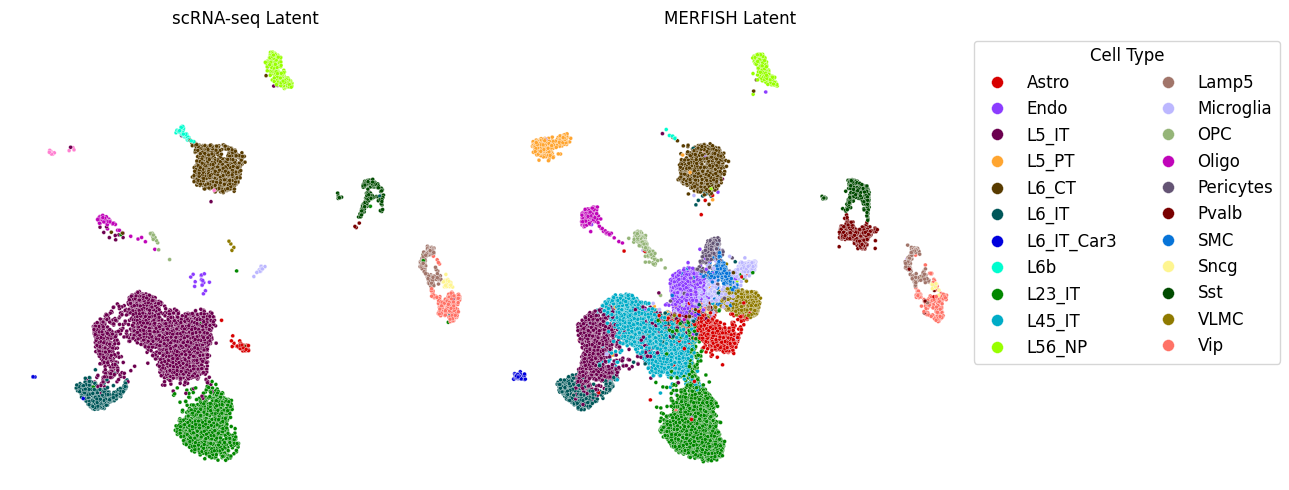

In [83]:


fit = umap.UMAP(
    n_neighbors = 100,
    min_dist = 0.3,
    n_components = 2,
)

latent_umap = fit.fit_transform(np.concatenate([st_data.obsm['envi_latent'], sc_data.obsm['envi_latent']], axis = 0))

st_data.obsm['latent_umap'] = latent_umap[:st_data.shape[0]]
sc_data.obsm['latent_umap'] = latent_umap[st_data.shape[0]:]

lim_arr = np.concatenate([st_data.obsm['latent_umap'], sc_data.obsm['latent_umap']], axis = 0)


delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta 
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta 
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta
fig = plt.figure(figsize = (13,5))
plt.subplot(121)
sns.scatterplot(x = sc_data.obsm['latent_umap'][:, 0], 
                y = sc_data.obsm['latent_umap'][:, 1], hue = sc_data.obs['cell_type'], s = 8, palette = cell_type_palette, 
                legend = False)
plt.title("scRNA-seq Latent")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')

plt.subplot(122)
sns.scatterplot(x = st_data.obsm['latent_umap'][:, 0], 
                y = st_data.obsm['latent_umap'][:, 1],  hue = st_data.obs['cell_type'], s = 8, palette = cell_type_palette, legend = True)


legend = plt.legend(title = 'Cell Type', prop={'size': 12}, fontsize = '12',  markerscale = 3, ncol = 2, bbox_to_anchor = (1, 1))#, loc = 'lower left')
plt.setp(legend.get_title(),fontsize='12')
plt.title("MERFISH Latent")
plt.axis('off')
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.show()

## Covet sqrt umap for both SC and ST separately

/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


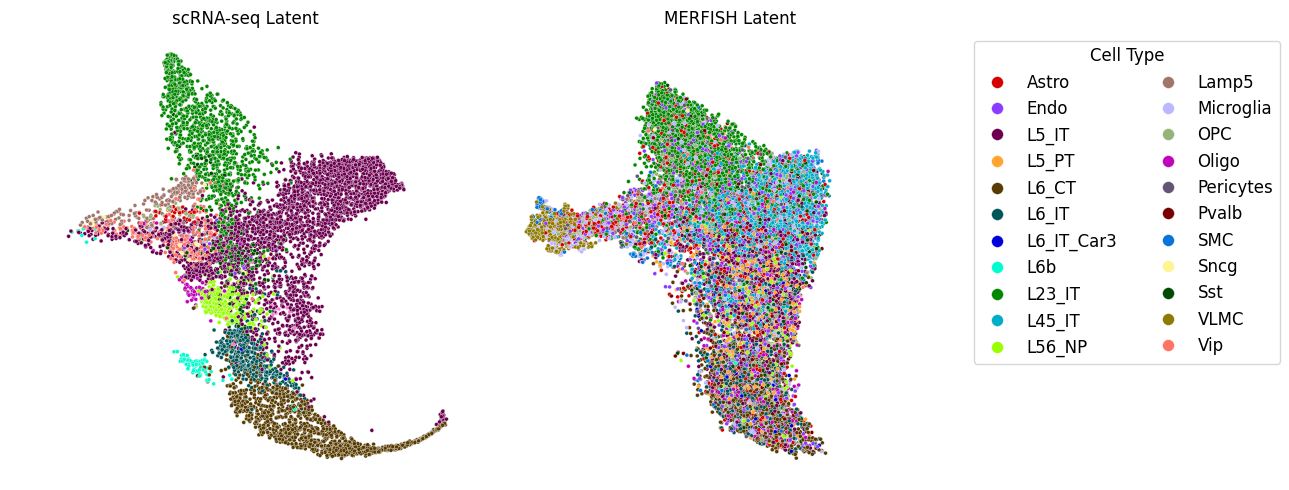

In [18]:


fit = umap.UMAP(
    n_neighbors = 100,
    min_dist = 0.3,
    n_components = 2,
)

# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_data.obsm["COVET_SQRT"].reshape(st_data.shape[0], -1)
sc_covet_sqrt_flat = sc_data.obsm["COVET_SQRT"].reshape(sc_data.shape[0], -1)

# Combine both datasets for joint UMAP
covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)


covet_umap = fit.fit_transform(covet_sqrt_combined)

st_data.obsm['covet_umap'] = covet_umap[:st_data.shape[0]]
sc_data.obsm['covet_umap'] = covet_umap[st_data.shape[0]:]

lim_arr = np.concatenate([st_data.obsm['covet_umap'], sc_data.obsm['covet_umap']], axis = 0)


delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta 
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta 
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta
fig = plt.figure(figsize = (13,5))
plt.subplot(121)
sns.scatterplot(x = sc_data.obsm['covet_umap'][:, 0], 
                y = sc_data.obsm['covet_umap'][:, 1], hue = sc_data.obs['cell_type'], s = 8, palette = cell_type_palette, 
                legend = False)
plt.title("scRNA-seq Latent")
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.axis('off')

plt.subplot(122)
sns.scatterplot(x = st_data.obsm['covet_umap'][:, 0], 
                y = st_data.obsm['covet_umap'][:, 1],  hue = st_data.obs['cell_type'], s = 8, palette = cell_type_palette, legend = True)


legend = plt.legend(title = 'Cell Type', prop={'size': 12}, fontsize = '12',  markerscale = 3, ncol = 2, bbox_to_anchor = (1, 1))#, loc = 'lower left')
plt.setp(legend.get_title(),fontsize='12')
plt.title("MERFISH Latent")
plt.axis('off')
plt.tight_layout()
plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.show()

## Envi latent combined UMAP

In [118]:
envi_latent_sc= sc_data.obsm['envi_latent']
envi_latent_st=st_data.obsm['envi_latent']
print (envi_latent_sc.shape)
print(envi_latent_st.shape)
envi_latent_combined= np.concatenate([st_data.obsm['envi_latent'], sc_data.obsm['envi_latent']], axis = 0)
print(envi_latent_combined.shape)

(7416, 512)
(18516, 512)
(25932, 512)


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


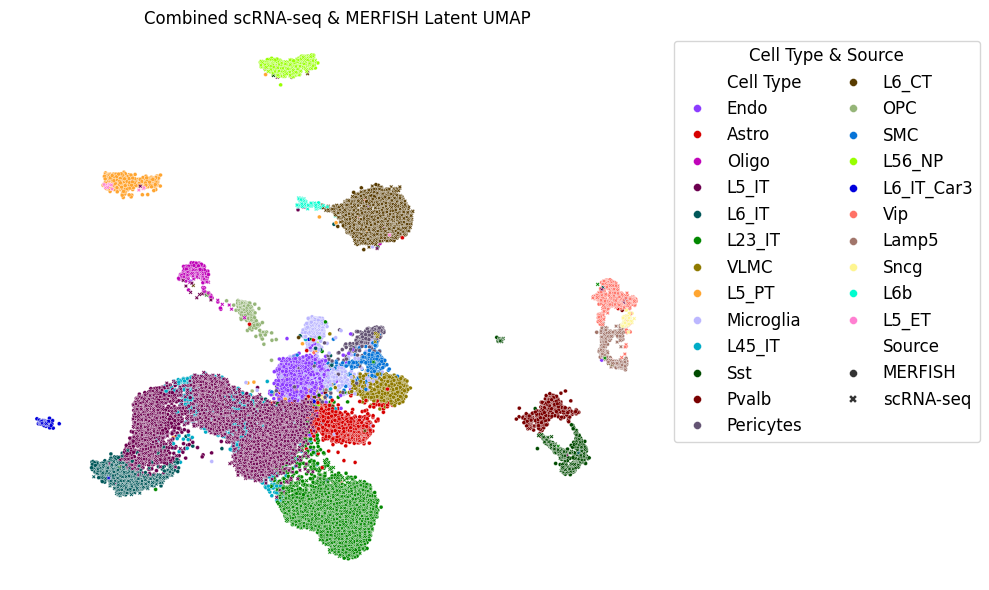

In [131]:
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fit UMAP on combined latent spaces
fit = umap.UMAP(n_neighbors=100, min_dist=0.3, n_components=2)
latent_umap = fit.fit_transform(np.concatenate([st_data.obsm['envi_latent'], sc_data.obsm['envi_latent']], axis=0))

# Assign UMAP coordinates to ST and SC data
st_data.obsm['latent_umap'] = latent_umap[:st_data.shape[0]]
sc_data.obsm['latent_umap'] = latent_umap[st_data.shape[0]:]

# Create a dataframe for visualization
st_df = pd.DataFrame(st_data.obsm['latent_umap'], columns=['UMAP1', 'UMAP2'])
st_df['Cell Type'] = st_data.obs['cell_type'].values
st_df['Source'] = 'MERFISH'

sc_df = pd.DataFrame(sc_data.obsm['latent_umap'], columns=['UMAP1', 'UMAP2'])
sc_df['Cell Type'] = sc_data.obs['cell_type'].values
sc_df['Source'] = 'scRNA-seq'

# Combine both dataframes
combined_df = pd.concat([st_df, sc_df], ignore_index=True)

# Set plot limits
lim_arr = latent_umap
delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta

# Plot all data in a single scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_df, x='UMAP1', y='UMAP2', hue='Cell Type', style='Source', s=8, palette=cell_type_palette)

# Customize legend
legend = plt.legend(title='Cell Type & Source', prop={'size': 12}, fontsize=12, markerscale=2, ncol=2, bbox_to_anchor=(1, 1))
plt.setp(legend.get_title(), fontsize='12')

plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.title("Combined scRNA-seq & MERFISH Latent UMAP")
plt.axis('off')
plt.tight_layout()
plt.show()


In [123]:
sc_cell_labels = sc_data.obsm['cell_type_niche']
st_cell_labels = st_data.obsm['cell_type_niche']
combined_labels = np.concatenate([st_cell_labels, sc_cell_labels])
print(combined_labels.shape)

(25932, 22)


In [129]:
print("Shape of combined_labels:", combined_labels.shape)
print("Expected number of columns (cell types):", len(cell_types))


Shape of combined_labels: (25932, 22)
Expected number of columns (cell types): 25932


In [ ]:
print(st_data.obsm['cell_type_niche'].shape)
print(sc_data.obsm['cell_type_niche'].shape)


(18516, 22)
(7416, 22)


In [97]:
st_data.obsm['cell_type_niche']

,Astro,Endo,L23_IT,L45_IT,L56_NP,L5_IT,L5_PT,L6_CT,L6_IT,L6_IT_Car3,...,Microglia,OPC,Oligo,Pericytes,Pvalb,SMC,Sncg,Sst,VLMC,Vip
12,0.0,2.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0
32,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
47,0.0,0.0,1.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
52,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280291,2.0,0.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
280296,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,0.0
280301,1.0,2.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
280315,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [107]:
sc_data.obsm['cell_type_niche']

,Astro,Endo,L23_IT,L45_IT,L56_NP,L5_IT,L5_PT,L6_CT,L6_IT,L6_IT_Car3,...,Microglia,OPC,Oligo,Pericytes,Pvalb,SMC,Sncg,Sst,VLMC,Vip
AAACCCAGTAGGACTG-4L8TX_181211_01_B01,0.6,0.6,1.4,5.4,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTCCACTTC-4L8TX_181211_01_B01,0.4,0.8,1.2,5.6,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTGCTCGTG-4L8TX_181211_01_B01,0.2,0.4,1.2,6.0,0.0,0.2,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTGGATTTC-4L8TX_181211_01_B01,0.0,0.4,0.0,0.0,0.0,0.0,0.4,5.2,1.4,0.0,...,0.2,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAACCCAGTTCTTGCC-4L8TX_181211_01_B01,0.2,0.4,5.6,1.8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTTACCCTC-4L8TX_181211_01_B01,0.0,0.8,0.0,6.4,0.0,0.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTTGTCAAATGCC-4L8TX_181211_01_B01,0.2,0.8,0.2,5.8,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTTGTCCACACCT-4L8TX_181211_01_B01,0.2,0.8,2.4,4.6,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TTTGTTGTCCTCATAT-4L8TX_181211_01_B01,0.0,0.6,6.4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Mapping the cell types to cell labels

In [102]:
import pandas as pd
cell_type_to_label = {
    'Pvalb': 'GABAergic',
    'Sst': 'GABAergic',
    'Vip': 'GABAergic',
    'Sncg': 'GABAergic',
    'L23_IT': 'Glutamatergic',
    'L45_IT': 'Glutamatergic',
    'L56_NP': 'Glutamatergic',
    'L5_IT': 'Glutamatergic',
    'L5_PT': 'Glutamatergic',
    'L6_CT': 'Glutamatergic',
    'L6_IT': 'Glutamatergic',
    'L6_IT_Car3': 'Glutamatergic',
    'Astro': 'Non-Neuronal',
    'Oligo': 'Non-Neuronal',
    'OPC': 'Non-Neuronal',
    'Microglia': 'Non-Neuronal',
    'Endo': 'Non-Neuronal',
    'Pericytes': 'Non-Neuronal',
    'SMC': 'Non-Neuronal',
    'VLMC': 'Non-Neuronal'
}



## COVET SQRT COMBINED UMAP

In [ ]:
COVET_SQRT_sc= sc_data.obsm['COVET_SQRT']
COVET_SQRT_st=st_data.obsm['COVET_SQRT']
COVET_SQRT_combined= np.concatenate([st_data.obsm['COVET_SQRT'], sc_data.obsm['COVET_SQRT']], axis = 0)
print(COVET_SQRT_combined.shape)

In [ ]:
COVET_SQRT_combined = COVET_SQRT_combined.reshape(COVET_SQRT_combined.shape[0], -1)
print(COVET_SQRT_combined.shape)

In [ ]:
covet_sqrt_PCA=sc.tl.pca(COVET_SQRT_combined, n_comps=100, svd_solver='arpack')


/opt/anaconda3/envs/octopus/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


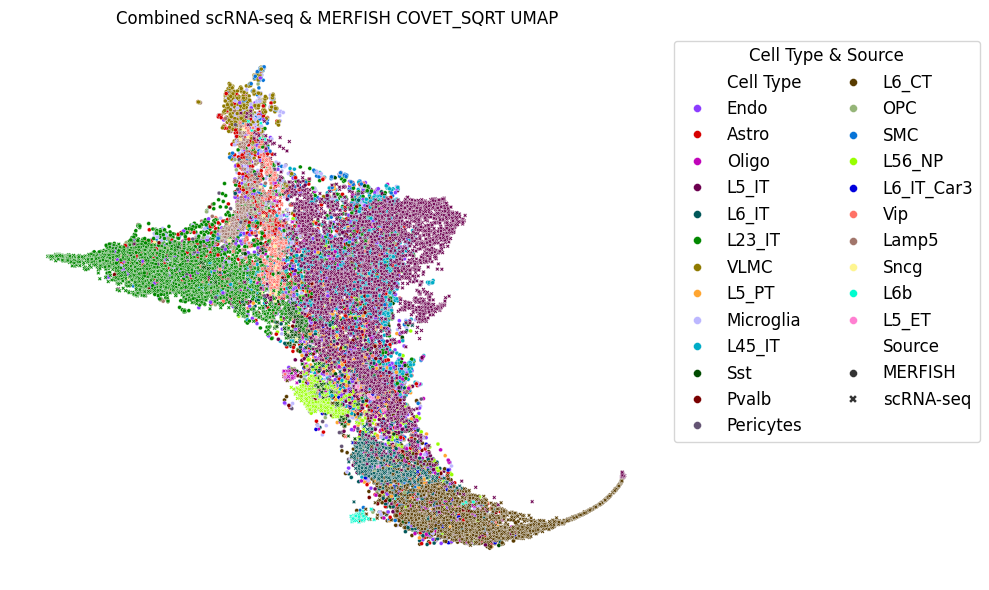

In [136]:
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Fit UMAP on combined COVET_SQRT latent spaces
fit = umap.UMAP(
    n_neighbors=50,   # Reduce for local structure
    min_dist=0.1,    # Tighter clusters
    n_components=2
)
# Flatten the (64, 64) matrices into 1D vectors
st_covet_sqrt_flat = st_data.obsm["COVET_SQRT"].reshape(st_data.shape[0], -1)
sc_covet_sqrt_flat = sc_data.obsm["COVET_SQRT"].reshape(sc_data.shape[0], -1)

# Combine both datasets for joint UMAP
covet_sqrt_combined = np.concatenate([st_covet_sqrt_flat, sc_covet_sqrt_flat], axis=0)
covet_umap = fit.fit_transform(covet_sqrt_combined)

# Assign UMAP coordinates to ST and SC data
st_data.obsm['covet_umap'] = covet_umap[:st_data.shape[0]]
sc_data.obsm['covet_umap'] = covet_umap[st_data.shape[0]:]

# Create DataFrame for plotting
st_df = pd.DataFrame(st_data.obsm['covet_umap'], columns=['UMAP1', 'UMAP2'])
st_df['Cell Type'] = st_data.obs['cell_type'].values
st_df['Source'] = 'MERFISH'

sc_df = pd.DataFrame(sc_data.obsm['covet_umap'], columns=['UMAP1', 'UMAP2'])
sc_df['Cell Type'] = sc_data.obs['cell_type'].values
sc_df['Source'] = 'scRNA-seq'

# Combine both dataframes
combined_df = pd.concat([st_df, sc_df], ignore_index=True)

# Set plot limits
lim_arr = covet_umap
delta = 1
pre = 0.1
xmin = np.percentile(lim_arr[:, 0], pre) - delta
xmax = np.percentile(lim_arr[:, 0], 100 - pre) + delta
ymin = np.percentile(lim_arr[:, 1], pre) - delta
ymax = np.percentile(lim_arr[:, 1], 100 - pre) + delta

# Plot all data in a single scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=combined_df, x='UMAP1', y='UMAP2', hue='Cell Type', style='Source', s=8, palette=cell_type_palette)

# Customize legend
legend = plt.legend(title='Cell Type & Source', prop={'size': 12}, fontsize=12, markerscale=2, ncol=2, bbox_to_anchor=(1, 1))
plt.setp(legend.get_title(), fontsize='12')

plt.xlim([xmin, xmax])
plt.ylim([ymin, ymax])
plt.title("Combined scRNA-seq & MERFISH COVET_SQRT UMAP")
plt.axis('off')
plt.tight_layout()
plt.show()


## PREDICTING METACELLS USING ONLY ENVI LATENT COMBINED

### 1. APPLYING PCA

In [ ]:
envi_latent_pca=sc.tl.pca(envi_latent_combined, n_comps=50, svd_solver='arpack')

### 2. COMPUTING KNN INDICES

In [148]:

envi_adata_combined = sc.AnnData(envi_latent_combined)

sc.pp.neighbors(envi_adata_combined, n_neighbors=15, use_rep="X", method='umap')  # 'X' contains ENVI latent
print("knn graph computed")
print (" This will compute the pairwise distance matrix between neighbors and the weighted adjacency matrix for the KNN graph" )



knn graph computed
 This will compute the pairwise distance matrix between neighbors and the weighted adjacency matrix for the KNN graph


In [152]:
from sklearn.neighbors import NearestNeighbors
X = envi_latent_combined  # Ensure this contains latent features
n_neighbors = 15

nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='auto', n_jobs=-1).fit(X)
distances, indices = nbrs.kneighbors(X)

# Store them manually in .uns
envi_adata_combined.uns["neighbors"]["indices"] = indices

In [149]:
print(envi_adata_combined.obsp["connectivities"])

  (0, 2863)	0.12698395550251007
  (0, 5322)	0.29372134804725647
  (0, 6327)	0.6005662083625793
  (0, 6532)	1.0
  (0, 8430)	0.12784545123577118
  (0, 9748)	0.10454447567462921
  (0, 14508)	0.1329236477613449
  (0, 14987)	0.1680210828781128
  (0, 15998)	0.21830369532108307
  (0, 16017)	0.30446508526802063
  (0, 17509)	0.17435991764068604
  (0, 20710)	0.1278047114610672
  (0, 22988)	0.10187142342329025
  (0, 23254)	0.4254837930202484
  (1, 2485)	0.6508379578590393
  (1, 7244)	0.0669327899813652
  (1, 8554)	0.06851188838481903
  (1, 10812)	0.2658252716064453
  (1, 13062)	0.17586004734039307
  (1, 15312)	0.5964834094047546
  (1, 16613)	0.09191805869340897
  (1, 19455)	0.12240906059741974
  (1, 19493)	0.07200252264738083
  (1, 20097)	0.469307541847229
  (1, 20188)	0.07448241114616394
  :	:
  (25931, 8569)	1.0
  (25931, 9761)	0.173400416970253
  (25931, 11899)	0.39574477076530457
  (25931, 12225)	0.4200749695301056
  (25931, 14978)	0.29035669565200806
  (25931, 16314)	0.2028966248035431
  (25

In [153]:
print(envi_adata_combined.uns.get("neighbors", {}).keys())


dict_keys(['connectivities_key', 'distances_key', 'params', 'indices'])


In [155]:
knn_indices = envi_adata_combined.uns["neighbors"]["indices"]  # Indices of nearest neighbors
print(knn_indices.shape)  # Should match (n_samples, n_neighbors)


(25932, 15)


## 3. CALCULATING SNN FOR ENVI LATENT COMBINED

In [156]:
connectivities = envi_adata_combined.obsp["connectivities"].toarray()  # Convert sparse matrix to dense


In [158]:
import scipy.sparse as sp

# Compute SNN as (A @ A.T), where A is the binary adjacency matrix of neighbors
binary_knn_graph = (connectivities > 0).astype(float)  # Convert to binary (0/1)
snn_matrix = binary_knn_graph @ binary_knn_graph.T  # Shared neighbors count

# Normalize by n_neighbors to get a similarity score
snn_matrix /= 15.0  # Assuming n_neighbors = 15

# Store as sparse matrix to save memory
envi_adata_combined.obsp["snn"] = sp.csr_matrix(snn_matrix)

print("SNN matrix computation complete and stored in envi_adata_combined.obsp['snn'].")

SNN matrix computation complete and stored in envi_adata_combined.obsp['snn'].


In [163]:
print(envi_adata_combined.uns["neighbors"].keys())  # Should contain 'connectivities'


dict_keys(['connectivities_key', 'distances_key', 'params', 'indices'])


In [ ]:
sc.tl.leiden(envi_adata_combined, resolution=1.0, key_added="metacell")


/var/folders/d4/bgr0tr5d43z2xmtq5hk3s4n00000gn/T/ipykernel_60189/16762520.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(envi_adata_combined, resolution=1.0, key_added="metacell")


In [168]:
sc.tl.umap(envi_adata_combined)


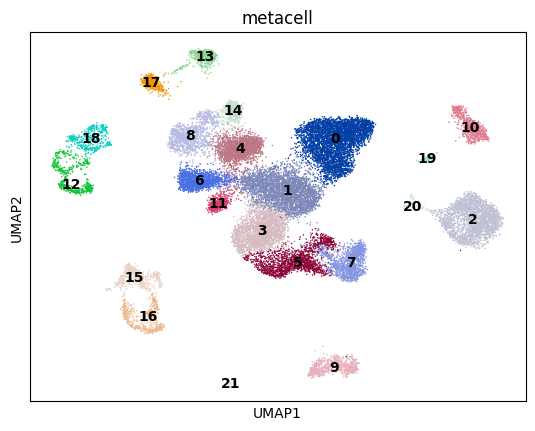

In [169]:
sc.pl.umap(envi_adata_combined, color="metacell", legend_loc="on data")


In [170]:
import metacells as mc

# Compute metacells using Metacell-2
mc.tl.build_metacells(
    envi_adata_combined,
    target_metacell_size=50  # Adjust based on dataset size
)

# Check the assigned metacell labels
print(envi_adata_combined.obs["metacell"])  # Should contain metacell IDs


AttributeError: module 'metacells.tools' has no attribute 'build_metacells'